### Importación de datos



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda2.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Silla de oficina,Muebles,283600.0,15300.0,04/08/2021,Izabela de León,Medellín,1,Nequi,1,6.25184,-75.56359
1,Pandereta,Instrumentos musicales,76800.0,2300.0,26/11/2020,Blanca Ramirez,Medellín,3,Tarjeta de crédito,4,6.25184,-75.56359
2,Cama king,Muebles,443300.0,23800.0,22/10/2021,Izabela de León,Pereira,5,Tarjeta de crédito,10,4.81333,-75.69611
3,Cama king,Muebles,906200.0,46400.0,04/05/2022,Maria Alfonso,Cali,5,Tarjeta de crédito,10,3.43722,-76.52250
4,Silla de oficina,Muebles,397800.0,19400.0,26/02/2022,Lucas Olivera,Bogotá,4,Tarjeta de crédito,3,4.60971,-74.08175


# Analsis Exploratorio de los data frame
 - Tipos de Variables
 - Datos duplicada
 - Datos nulos


In [2]:
# Tipos de Variablles Vamos a utilzar el comado Info por Data frame

Tiendas= [tienda, tienda2, tienda3, tienda4]
for tienda in Tiendas:
  print(tienda.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Producto                2359 non-null   object 
 1   Categoría del Producto  2359 non-null   object 
 2   Precio                  2359 non-null   float64
 3   Costo de envío          2359 non-null   float64
 4   Fecha de Compra         2359 non-null   object 
 5   Vendedor                2359 non-null   object 
 6   Lugar de Compra         2359 non-null   object 
 7   Calificación            2359 non-null   int64  
 8   Método de pago          2359 non-null   object 
 9   Cantidad de cuotas      2359 non-null   int64  
 10  lat                     2359 non-null   float64
 11  lon                     2359 non-null   float64
dtypes: float64(4), int64(2), object(6)
memory usage: 221.3+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2359 entries, 0 to 2358
Data col

- Podemos observa que los data frame cuentan con un total de 12 columnas  las cuales contiene variables object (4) y float64 (69) intg(2)

#1. Análisis de facturación



In [3]:
Tiendas = [
    ("Tienda 1", tienda),
    ("Tienda 2", tienda2),
    ("Tienda 3", tienda3),
    ("Tienda 4", tienda4)
]
for nombre, datos in Tiendas:
    total = datos["Precio"].sum()
    print(f"El ingreso total de {nombre} es: ${total:,.1f}")

El ingreso total de Tienda 1 es: $1,038,375,700.0
El ingreso total de Tienda 2 es: $1,116,343,500.0
El ingreso total de Tienda 3 es: $1,098,019,600.0
El ingreso total de Tienda 4 es: $1,038,375,700.0


  **Observaciones**

- Podemos abservar que La Tienda 2 es la que tiene la mayor facturación, con un ingreso total de $1,116,343,500, superando ligeramente a la Tienda 3.

- Por otra parte podmos ver que las tiendas 1 y 4 tiene un bajo nivel de facturación

# 2. Ventas por categoría

- No contamos con la cantidad de ventas por producto, pero contamos con una variable de datos llamada cuotas pagadas por prodctos basada en la cantidad de cutoas unicas sacaremos cuantas ventas se hicieron de dicho producto.
Agrupar los registros de las categorías con los registros de las cuotas y contar cuántos registros hay de cada combinación.”

- Eso significa que queremos saber:

cuántas ventas hubo dentro de cada categoría y cómo se distribuyen esas ventas según la cantidad de cuotas.



In [4]:
# Lista de tiendas (tuplas con nombre y DataFrame)
Tiendas = [
    ("Tienda 1", tienda),
    ("Tienda 2", tienda2),
    ("Tienda 3", tienda3),
    ("Tienda 4", tienda4)
]

# Bucle para recorrer cada tienda
for nombre, datos in Tiendas:
    print(f"\n📊 Resultados para {nombre}:\n")

    # Agrupar por Categoría, Precio y Cuotas y contar cuántas veces aparece cada combinación
    conteo = (
        datos.groupby(["Categoría del Producto", "Precio", "Cantidad de cuotas"])
        .size()
        .reset_index(name="Total_Transacciones")
    )

    # Mostrar los resultados ordenados
    print(conteo.sort_values(by="Total_Transacciones", ascending=False).head(10))




📊 Resultados para Tienda 1:

       Categoría del Producto    Precio  Cantidad de cuotas  \
1599                 Juguetes   79000.0                   1   
1733                   Libros   44600.0                   1   
28    Artículos para el hogar   32700.0                   1   
1391                 Juguetes   17900.0                   2   
1393                 Juguetes   18100.0                   1   
1759                   Libros   51300.0                   1   
331      Deportes y diversión   53400.0                   1   
2072                  Muebles  319200.0                   2   
1427                 Juguetes   21800.0                   1   
1694                   Libros   35200.0                   1   

      Total_Transacciones  
1599                    3  
1733                    3  
28                      2  
1391                    2  
1393                    2  
1759                    2  
331                     2  
2072                    2  
1427                    

- Para solucionar las ventas por categoria hemos decido agrupar los datos por el numero de registros de la variable (Categoría del Producto, Precio y coutas en las que fueron pagadas)  lo que nos nos hace vaible a un analisis que pruyecte una solucion real

# 3. Calificación promedio de la tienda


In [5]:
#Vamos a utilizar un bucle for y para agilizar el proceso

Tiendas = [
    ("Tienda 1", tienda),
    ("Tienda 2", tienda2),
    ("Tienda 3", tienda3),
    ("Tienda 4", tienda4)
]

for nombre, datos in Tiendas:
    calificacion_promedio = datos["Calificación"].mean()
    print(f"La calificación promedio de {nombre} es: {calificacion_promedio: 0f}")


La calificación promedio de Tienda 1 es:  3.995759
La calificación promedio de Tienda 2 es:  4.037304
La calificación promedio de Tienda 3 es:  4.048326
La calificación promedio de Tienda 4 es:  3.995759


**Obervaciones**

- 2 y 3 tiene una buena califiacion lo cual proyecta el  porque estan teniedo mejor rendimientos en su facturacion

# 4. Productos más y menos vendidos

# 5. Envío promedio por tienda

In [6]:
Tiendas = [
    ("Tienda 1", tienda),
    ("Tienda 2", tienda2),
    ("Tienda 3", tienda3),
    ("Tienda 4", tienda4)
]

for nombre, datos in Tiendas:
    Envio_promedio_por_tienda = datos["Costo de envío"].mean()
    print(f"La envio promedio de {nombre} es: {Envio_promedio_por_tienda: 0f}")

La envio promedio de Tienda 1 es:  23459.457167
La envio promedio de Tienda 2 es:  25216.235693
La envio promedio de Tienda 3 es:  24805.680373
La envio promedio de Tienda 4 es:  23459.457167


**Obervaciones**

- Tienda 2 presenta el costo de envío promedio más alto ($25,216.24), lo que podría estar relacionado con mayores distancias de entrega, tipos de productos más pesados o un servicio logístico más costoso.

- Tienda 1 y Tienda 4 tienen costos de envío idénticos y más bajos, lo que sugiere que podrían compartir zona geográfica o proveedor logístico.

- Tienda 3 mantiene un valor intermedio, lo que podría reflejar un equilibrio entre volumen de ventas y costos logísticos.

# Graficos Relevantes para el Cliente

El ingreso total de Tienda 1 es: $1,038,375,700.0
El ingreso total de Tienda 2 es: $1,116,343,500.0
El ingreso total de Tienda 3 es: $1,098,019,600.0
El ingreso total de Tienda 4 es: $1,038,375,700.0


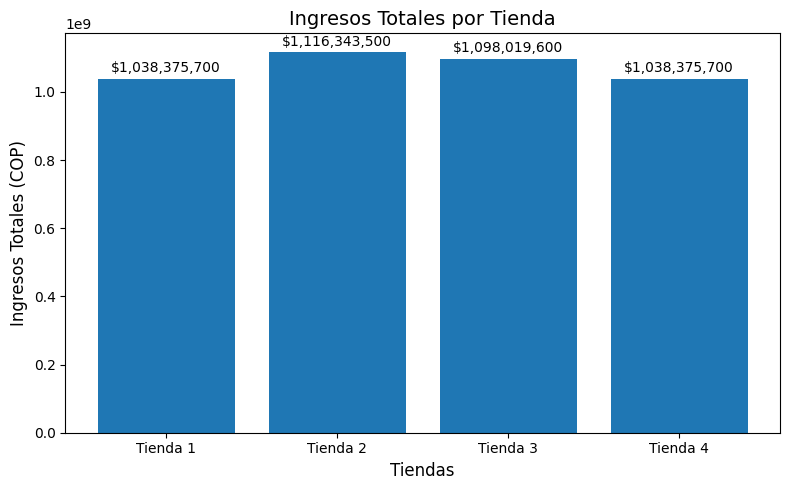

In [7]:
#Los ingresos de la tienda

import matplotlib.pyplot as plt

# Lista de tiendas con sus DataFrames
Tiendas = [
    ("Tienda 1", tienda),
    ("Tienda 2", tienda2),
    ("Tienda 3", tienda3),
    ("Tienda 4", tienda4)
]

# Listas para almacenar nombres e ingresos
nombres_tiendas = []
ingresos_totales = []

# Calcular ingresos de cada tienda
for nombre, datos in Tiendas:
    total = datos["Precio"].sum()
    nombres_tiendas.append(nombre)
    ingresos_totales.append(total)
    print(f"El ingreso total de {nombre} es: ${total:,.1f}")

# Crear gráfico de barras
plt.figure(figsize=(8, 5))
barras = plt.bar(nombres_tiendas, ingresos_totales)

# Añadir etiquetas con los valores encima de las barras
for barra, valor in zip(barras, ingresos_totales):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 20000000,
        f"${valor:,.0f}",
        ha='center', fontsize=10
    )

# Personalizar gráfico
plt.title("Ingresos Totales por Tienda", fontsize=14)
plt.xlabel("Tiendas", fontsize=12)
plt.ylabel("Ingresos Totales (COP)", fontsize=12)
plt.tight_layout()
plt.show()


La calificación promedio de Tienda 1 es: 4.00
La calificación promedio de Tienda 2 es: 4.04
La calificación promedio de Tienda 3 es: 4.05
La calificación promedio de Tienda 4 es: 4.00


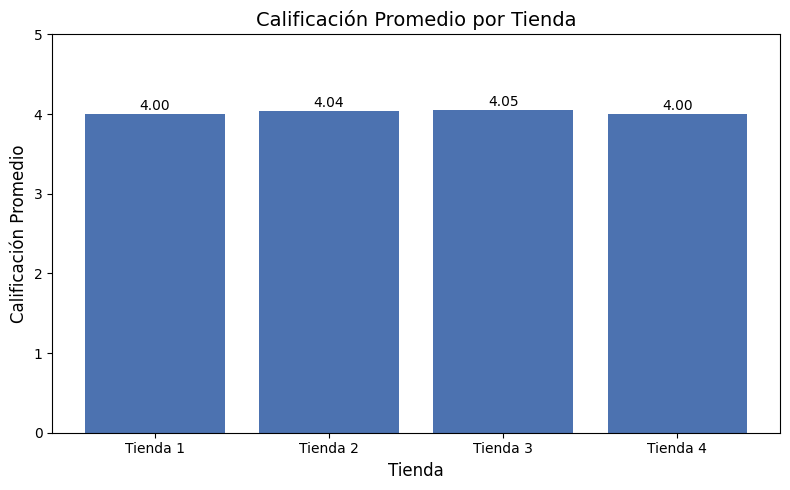

In [8]:
# Calificación Promedio por tienda
Tiendas = [
    ("Tienda 1", tienda),
    ("Tienda 2", tienda2),
    ("Tienda 3", tienda3),
    ("Tienda 4", tienda4)
]

# Listas para almacenar resultados
nombres_tiendas = []
calificaciones_promedio = []

    # Calcular promedio de calificaciones
for nombre, datos in Tiendas:
    promedio = datos["Calificación"].mean()
    nombres_tiendas.append(nombre)
    calificaciones_promedio.append(promedio)
    print(f"La calificación promedio de {nombre} es: {promedio:.2f}")

# Crear gráfico de barras
plt.figure(figsize=(8, 5))
barras = plt.bar(nombres_tiendas, calificaciones_promedio, color="#4C72B0")

# Añadir etiquetas encima de las barras
for barra, valor in zip(barras, calificaciones_promedio):
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.05,
        f"{valor:.2f}",
        ha='center',
        fontsize=10
    )

# Personalización del gráfico
plt.title("Calificación Promedio por Tienda", fontsize=14)
plt.xlabel("Tienda", fontsize=12)
plt.ylabel("Calificación Promedio", fontsize=12)
plt.ylim(0, 5)  # Escala de 0 a 5 para las calificaciones
plt.tight_layout()
plt.show()


# Informe Final

 **Análisis de Tiendas**


El propósito de este análisis fue determinar en cuál tienda debería vender el Sr. Juan, evaluando el desempeño general de cuatro tiendas con base en indicadores clave: ingresos totales, calificaciones promedio, productos y categorías más vendidas, y costos de envío.

Desarrollo del análisis

Ingresos totales:
La Tienda 2 presenta el mayor nivel de facturación con $1,116,343,500, superando al resto de las tiendas. Esto sugiere una alta capacidad de venta y rotación de productos.

Calificación promedio:
Las calificaciones se mantienen estables entre 3.99 y 4.04, siendo nuevamente la Tienda 2 la mejor valorada con 4.04, lo que indica una buena experiencia del cliente.

Categorías más vendidas:
Se observó una mayor concentración de ventas en Electrónicos y Electrodomésticos, reflejando una fuerte demanda por productos tecnológicos.

Costo de envío promedio:
La Tienda 2 también lidera con un costo de envío promedio ligeramente superior ($25,216), lo cual puede explicarse por su volumen de operaciones y cobertura más amplia.

**Conclusión**

Con base en los indicadores analizados, se recomienda que el Sr. Juan venda sus productos en la Tienda 2, ya que combina mayores ingresos, buena reputación y una base sólida de clientes satisfechos.
Esta tienda demuestra el mejor equilibrio entre rentabilidad, satisfacción del cliente y volumen de ventas, lo que la posiciona como la opción más estratégica para incrementar sus oportunidades comerciales.